
[O3N2-M13] offset statistics for NGC4396 (offsets relative to Σ* bin means):
  Σ_SFR global mean: -2.815
  Σ_SFR offset range: -1.313 to 1.638
  Σ_SFR offset max absolute: ±1.638
  [O/H] global mean: 8.413
  [O/H] offset range: -0.241 to 0.318
  [O/H] offset max absolute: ±0.318
  Number of Σ* bins: 12
  Valid pixels for Σ_SFR: 81745
  Valid pixels for [O/H]: 81745
  Common valid pixels: 81745


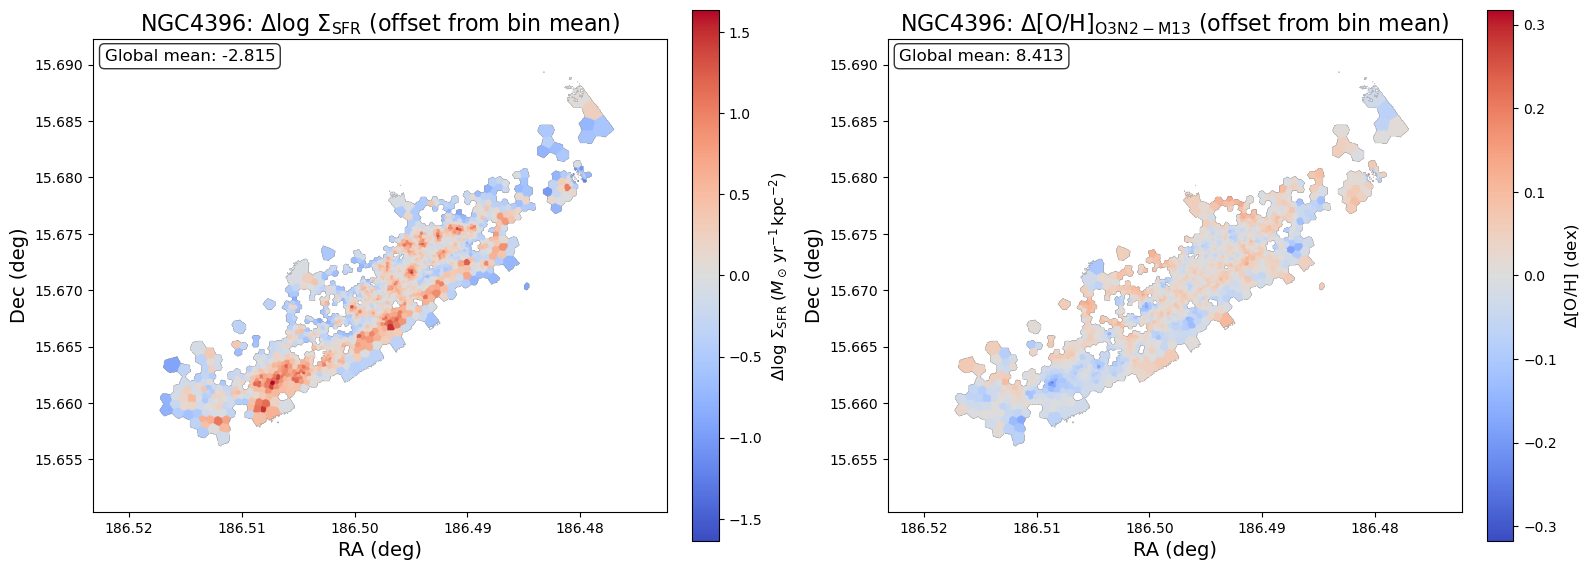

In [1]:
# ------------------------------------------------------------------
# 0.  Load NGC4396 maps and visualise Σ_SFR and [O/H] offset maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean_global = np.nanmean(sigSFR[valid_sfr])
    oh_mean_global = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: left = Σ_SFR offset, right = [O/H] offset
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add global mean value annotation on top left
    axes[0].text(0.02, 0.98, f'Global mean: {sfr_mean_global:.3f}', transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Right-hand side: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add global mean value annotation on top left
    axes[1].text(0.02, 0.98, f'Global mean: {oh_mean_global:.3f}', transform=axes[1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for the maps
    print(f"\n[{indicator_name}] offset statistics for {gal} (offsets relative to Σ* bin means):")
    print(f"  Σ_SFR global mean: {sfr_mean_global:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_all]):.3f} to {np.nanmax(sfr_offset[valid_all]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] global mean: {oh_mean_global:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_all]):.3f} to {np.nanmax(oh_offset[valid_all]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_offset_maps.png', dpi=600)
    plt.show()

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_44936/105732205.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


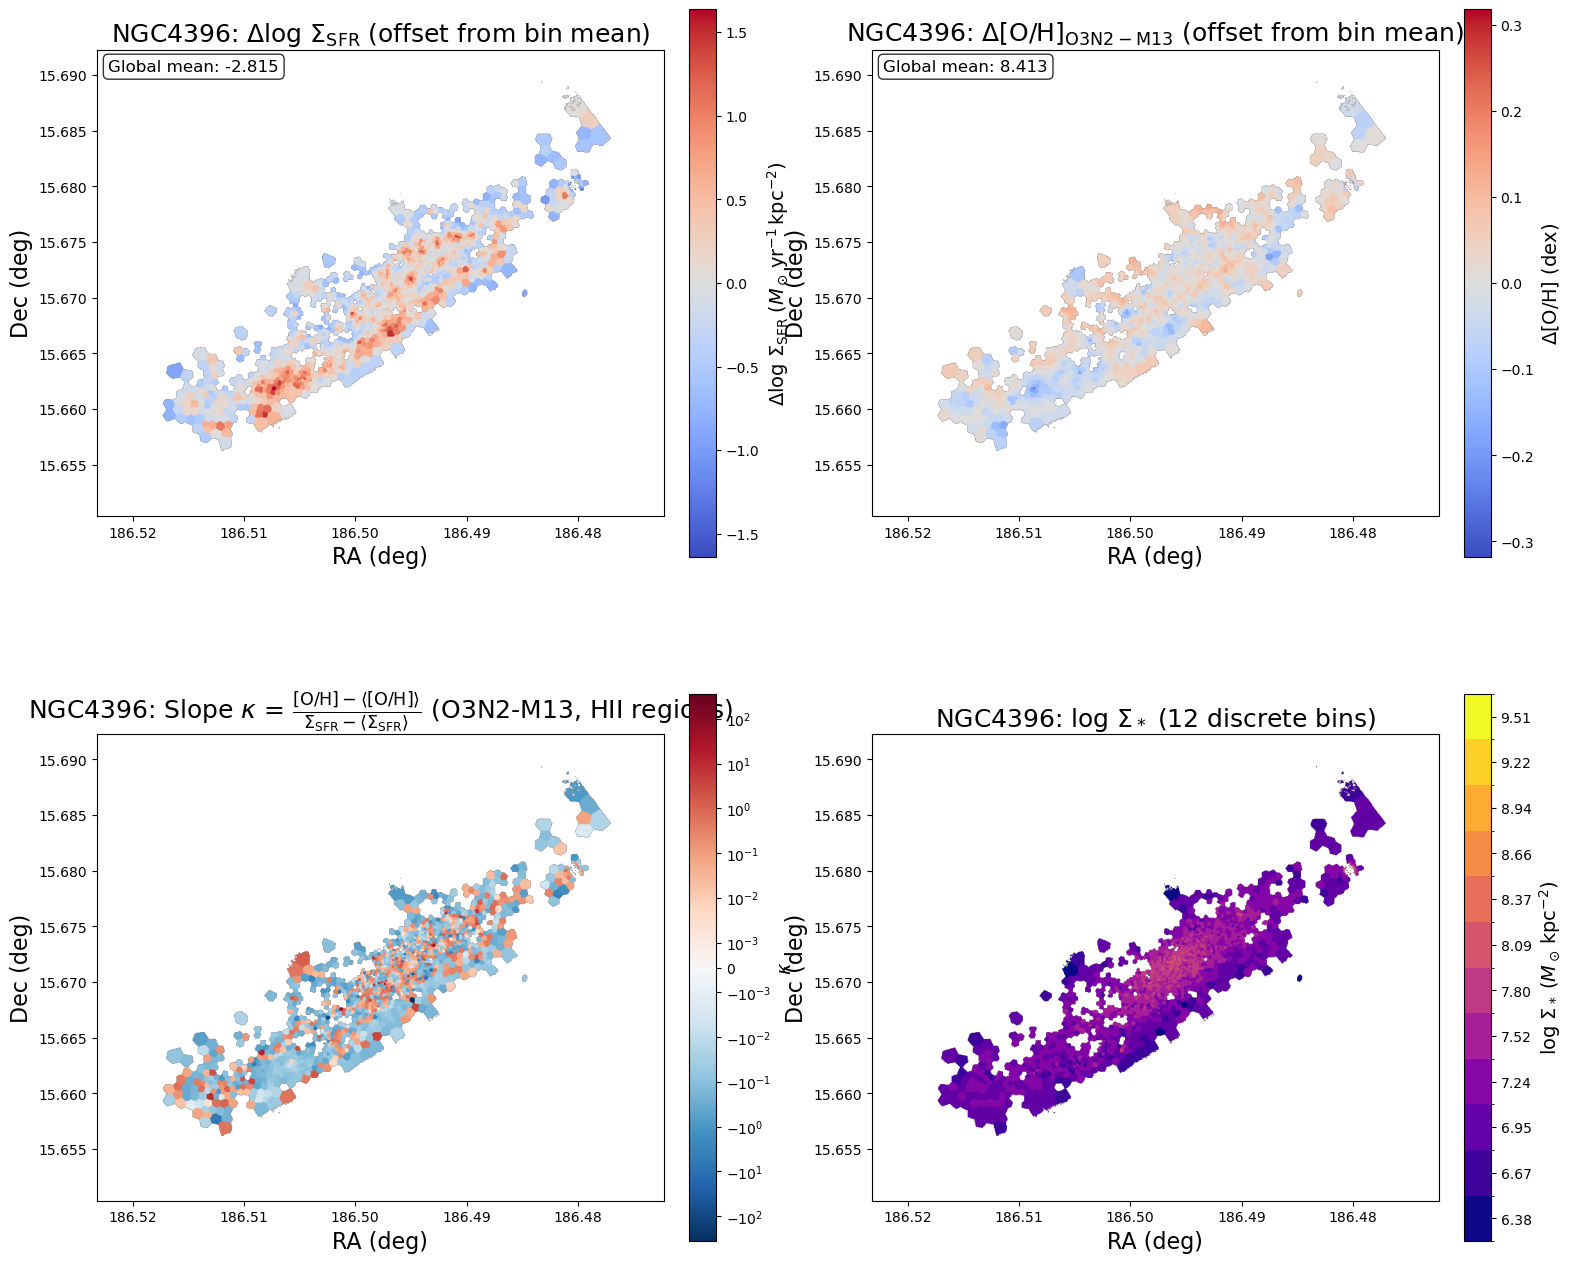


2x2 combined figure complete for NGC4396!
  Σ_SFR offset range: -1.638 to 1.638
  [O/H] offset range: -0.318 to 0.318
  κ range: -366.534 to 47.496
  Σ* bins: 12 bins from 6.241 to 9.651


In [2]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + slope map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate slope κ map
    # ------------------------------------------------------------------
    # Note: n_bins, sigmaM_bin_edges already defined in section 2
    kappa_map = np.full_like(sigM, np.nan)
    
    sigM_flat = sigM.flatten()
    sigSFR_flat = sigSFR.flatten()
    oh_flat = oh_o3n2_map.flatten()
    valid_all_flat = valid_all.flatten()
    kappa_flat = np.full_like(sigM_flat, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        elif i == n_bins - 1:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat <= sigmaM_bin_edges[i+1]) & valid_all_flat
        else:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        
        if np.sum(in_bin) > 0:
            x_bin = sigSFR_flat[in_bin]
            y_bin = oh_flat[in_bin]
            
            # Calculate the mean point: (x₀, y₀) = (mean(ΣSFR), mean([O/H]))
            x0 = np.mean(x_bin)
            y0 = np.mean(y_bin)
            
            dx = x_bin - x0
            dy = y_bin - y0
            
            kappa_bin = np.zeros_like(dx)
            nonzero_dx = np.abs(dx) > 1e-10
            kappa_bin[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
            kappa_bin[~nonzero_dx] = 0
            
            kappa_flat[in_bin] = kappa_bin
    
    kappa_map = kappa_flat.reshape(sigM.shape)

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    ax1.text(0.02, 0.98, f'Global mean: {sfr_mean:.3f}', transform=ax1.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)
    
    ax2.text(0.02, 0.98, f'Global mean: {oh_mean:.3f}', transform=ax2.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Slope κ map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    kappa_max = np.nanmax(np.abs(kappa_map[valid_all]))
    linthresh = 0.001
    linscale = 0.5
    
    norm_kappa = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                            vmin=-kappa_max, vmax=kappa_max)
    
    im_kappa = ax3.imshow(np.ma.masked_invalid(kappa_map), origin='lower', cmap='RdBu_r',
                          extent=extent, norm=norm_kappa)
    ax3.set_title(rf'{gal}: Slope $\kappa$ = $\frac{{[\mathrm{{O/H}}] - \langle[\mathrm{{O/H}}]\rangle}}{{\Sigma_{{\mathrm{{SFR}}}} - \langle\Sigma_{{\mathrm{{SFR}}}}\rangle}}$ ({indicator_name}, HII regions)', 
                  fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_kappa = fig.colorbar(im_kappa, ax=ax3, fraction=0.046, pad=0.04)
    cbar_kappa.set_label(r'$\kappa$', fontsize=14)

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'{gal}_correlation_map_kappa.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'{gal}_correlation_map_kappa.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  κ range: {np.nanmin(kappa_map[valid_all]):.3f} to {np.nanmax(kappa_map[valid_all]):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")


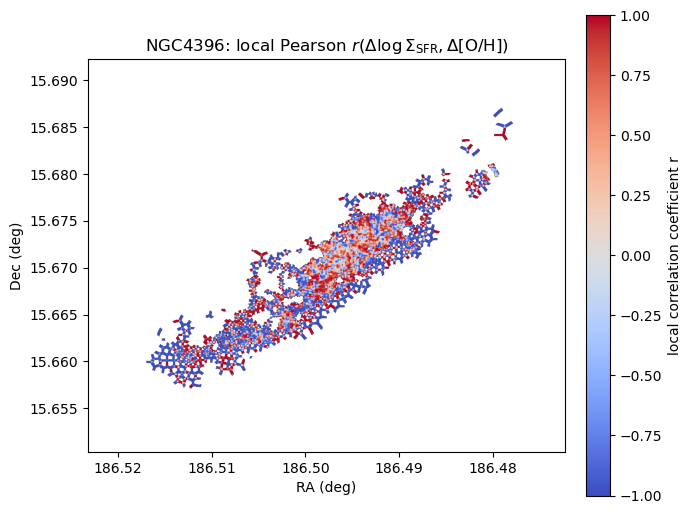

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def local_corr_map(A, B, valid_mask, half_win=2, min_n=10):
    """
    Compute a moving-window Pearson correlation between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    half_win : int
        Half window size in pixels (half_win=2 -> 5x5 window).
    min_n : int
        Minimum number of valid pixels in the window to compute a correlation.

    Returns
    -------
    corr_map : 2D array
        Map of local Pearson correlation coefficients in [-1, 1].
    """
    ny, nx = A.shape
    corr_map = np.full_like(A, np.nan, dtype=float)

    for i in range(ny):
        i0 = max(0, i - half_win)
        i1 = min(ny, i + half_win + 1)
        for j in range(nx):
            if not valid_mask[i, j]:
                continue
            j0 = max(0, j - half_win)
            j1 = min(nx, j + half_win + 1)

            win_valid = valid_mask[i0:i1, j0:j1]
            if np.count_nonzero(win_valid) < min_n:
                continue

            a_vals = A[i0:i1, j0:j1][win_valid]
            b_vals = B[i0:i1, j0:j1][win_valid]

            # need at least 2 unique values to define correlation
            if np.std(a_vals) == 0 or np.std(b_vals) == 0:
                continue

            r = np.corrcoef(a_vals, b_vals)[0, 1]
            corr_map[i, j] = r

    return corr_map

# --- compute and plot for NGC4396 ---
A = sfr_offset
B = oh_offset
valid = valid_all

corr_map = local_corr_map(A, B, valid_mask=valid, half_win=2, min_n=10)

fig, ax = plt.subplots(figsize=(7, 6))
v = np.nanmax(np.abs(corr_map))  # symmetric colour range
im = ax.imshow(np.ma.masked_invalid(corr_map), origin='lower',
               cmap='coolwarm', extent=extent, vmin=-v, vmax=v)
ax.set_title(r'NGC4396: local Pearson $r(\Delta\log\Sigma_{\rm SFR}, \Delta{\rm [O/H]})$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('local correlation coefficient r')

plt.tight_layout()
plt.show()


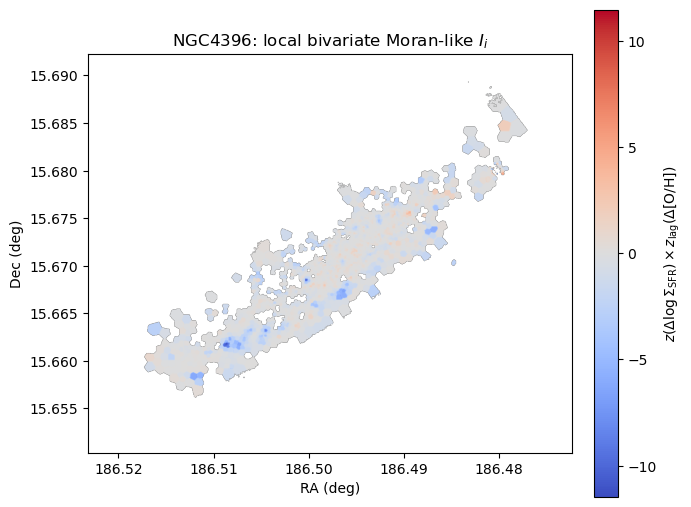

In [4]:
def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
    """
    Simple Moran-style local bivariate association between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    neighbourhood : {'queen', 'rook'}
        'queen' = 8-connected neighbours, 'rook' = 4-connected.

    Returns
    -------
    I_map : 2D array
        Local bivariate Moran-like statistic (sign & amplitude).
    quad_map : 2D int array
        Quadrant type:
        0 = invalid / no neighbours
        1 = high A, high lag(B)
        2 = low A,  high lag(B)
        3 = low A,  low lag(B)
        4 = high A, low lag(B)
    """
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)

    # standardise A,B on valid pixels only
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

    if neighbourhood == 'queen':
        offsets = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0), ( 1,1)]
    elif neighbourhood == 'rook':
        offsets = [(-1,0), (0,-1), (0,1), (1,0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue

            # collect neighbouring Bz values
            neigh_vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    neigh_vals.append(Bz[ii, jj])

            if len(neigh_vals) == 0:
                continue

            lag_B = np.mean(neigh_vals)   # spatial lag of B
            I_val = Az[i, j] * lag_B      # Moran-style product
            I_map[i, j] = I_val

            # quadrant classification (like LISA maps)
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1  # high A – high B_neigh
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2  # low A – high B_neigh
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3  # low A – low B_neigh
            else:
                quad_map[i, j] = 4  # high A – low B_neigh

    return I_map, quad_map

# --- compute and plot for NGC4396 ---
I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                        neighbourhood='queen')

# amplitude map
fig, ax = plt.subplots(figsize=(7, 6))
vI = np.nanmax(np.abs(I_map))
imI = ax.imshow(np.ma.masked_invalid(I_map), origin='lower',
                cmap='coolwarm', extent=extent, vmin=-vI, vmax=vI)
ax.set_title(r'NGC4396: local bivariate Moran-like $I_i$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
cbarI = fig.colorbar(imI, ax=ax, fraction=0.046, pad=0.04)
cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$')
plt.tight_layout()
plt.show()


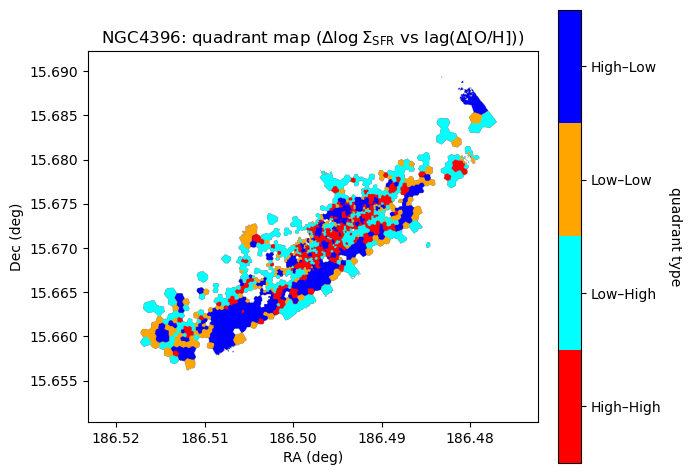

In [5]:
def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
    """
    Simple Moran-style local bivariate association between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    neighbourhood : {'queen', 'rook'}
        'queen' = 8-connected neighbours, 'rook' = 4-connected.

    Returns
    -------
    I_map : 2D array
        Local bivariate Moran-like statistic (sign & amplitude).
    quad_map : 2D int array
        Quadrant type:
        0 = invalid / no neighbours
        1 = high A, high lag(B)
        2 = low A,  high lag(B)
        3 = low A,  low lag(B)
        4 = high A, low lag(B)
    """
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)

    # standardise A,B on valid pixels only
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

    if neighbourhood == 'queen':
        offsets = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0), ( 1,1)]
    elif neighbourhood == 'rook':
        offsets = [(-1,0), (0,-1), (0,1), (1,0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue

            # collect neighbouring Bz values
            neigh_vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    neigh_vals.append(Bz[ii, jj])

            if len(neigh_vals) == 0:
                continue

            lag_B = np.mean(neigh_vals)   # spatial lag of B
            I_val = Az[i, j] * lag_B      # Moran-style product
            I_map[i, j] = I_val

            # quadrant classification (like LISA maps)
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1  # high A – high B_neigh
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2  # low A – high B_neigh
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3  # low A – low B_neigh
            else:
                quad_map[i, j] = 4  # high A – low B_neigh

    return I_map, quad_map

# --- compute and plot for NGC4396 ---
I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                        neighbourhood='queen')

# quad_map values:
# 0 = invalid / no neighbours
# 1 = High A – High lag(B)   (High–High)
# 2 = Low A  – High lag(B)   (Low–High)
# 3 = Low A  – Low lag(B)    (Low–Low)
# 4 = High A – Low lag(B)    (High–Low)

# mask invalid
quad_valid = np.where(quad_map == 0, np.nan, quad_map)

# we shift values from {1,2,3,4} -> {0,1,2,3} for nicer colourbar
quad_display = quad_valid - 1

quad_cmap = ListedColormap(['red', 'cyan', 'orange', 'blue'])
bounds = np.array([-0.5, 0.5, 1.5, 2.5, 3.5])  # bin edges
ticks = np.array([0, 1, 2, 3])                 # centres
ticklabels = ['High–High', 'Low–High', 'Low–Low', 'High–Low']

fig, ax = plt.subplots(figsize=(7, 6))
imQ = ax.imshow(np.ma.masked_invalid(quad_display),
                origin='lower', extent=extent,
                cmap=quad_cmap, vmin=-0.5, vmax=3.5)

ax.set_title(r'NGC4396: quadrant map ($\Delta\log\Sigma_{\rm SFR}$ vs lag($\Delta{\rm [O/H]}$))')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')

cbarQ = fig.colorbar(imQ, ax=ax, boundaries=bounds, ticks=ticks,
                     fraction=0.046, pad=0.04)
cbarQ.ax.set_yticklabels(ticklabels)
cbarQ.set_label('quadrant type', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


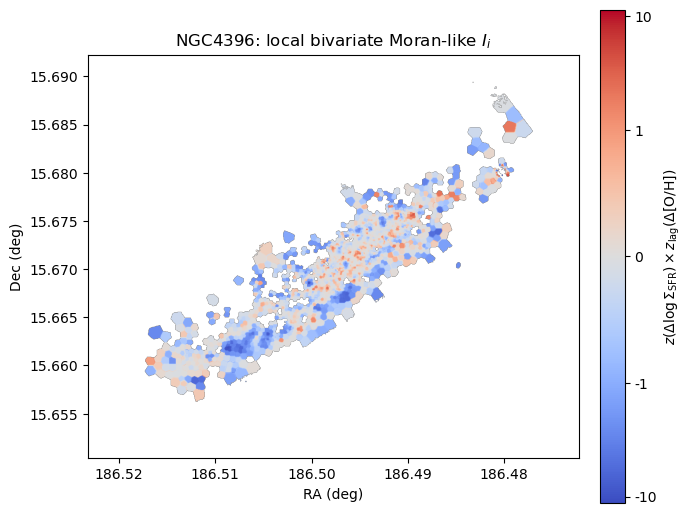

In [6]:
def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
    """
    Simple Moran-style local bivariate association between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    neighbourhood : {'queen', 'rook'}
        'queen' = 8-connected neighbours, 'rook' = 4-connected.

    Returns
    -------
    I_map : 2D array
        Local bivariate Moran-like statistic (sign & amplitude).
    quad_map : 2D int array
        Quadrant type:
        0 = invalid / no neighbours
        1 = high A, high lag(B)
        2 = low A,  high lag(B)
        3 = low A,  low lag(B)
        4 = high A, low lag(B)
    """
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)

    # standardise A,B on valid pixels only
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

    if neighbourhood == 'queen':
        offsets = [(-1,-1), (-1,0), (-1,1),
                   ( 0,-1),          ( 0,1),
                   ( 1,-1), ( 1,0), ( 1,1)]
    elif neighbourhood == 'rook':
        offsets = [(-1,0), (0,-1), (0,1), (1,0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue

            # collect neighbouring Bz values
            neigh_vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    neigh_vals.append(Bz[ii, jj])

            if len(neigh_vals) == 0:
                continue

            lag_B = np.mean(neigh_vals)   # spatial lag of B
            I_val = Az[i, j] * lag_B      # Moran-style product
            I_map[i, j] = I_val

            # quadrant classification (like LISA maps)
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1  # high A – high B_neigh
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2  # low A – high B_neigh
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3  # low A – low B_neigh
            else:
                quad_map[i, j] = 4  # high A – low B_neigh

    return I_map, quad_map

# --- compute and plot for NGC4396 ---
I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                        neighbourhood='queen')

fig, ax = plt.subplots(figsize=(7, 6))

# max absolute value for symmetric limits
vI = np.nanmax(np.abs(I_map))

# Symmetric log-normalisation:
#  - linthresh=1.0   → values between -1 and 1 are on a linear scale
#  - outside this, log10 scaling, symmetric around 0
norm = SymLogNorm(linthresh=1.0, linscale=1.0,
                  vmin=-vI, vmax=vI, base=10)

imI = ax.imshow(np.ma.masked_invalid(I_map), origin='lower',
                cmap='coolwarm', extent=extent, norm=norm)

ax.set_title(r'NGC4396: local bivariate Moran-like $I_i$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')

cbarI = fig.colorbar(imI, ax=ax, fraction=0.046, pad=0.04)
cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$')

# Nice symmetric log-style ticks (…,-10,-3,-1,0,1,3,10,…)
max_pow = int(np.floor(np.log10(vI)))
pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
ticks = [-p for p in reversed(pos_ticks)] + [0.0] + pos_ticks
cbarI.set_ticks(ticks)
cbarI.set_ticklabels([f'{t:g}' for t in ticks])

plt.tight_layout()
plt.show()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_44936/1396753989.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


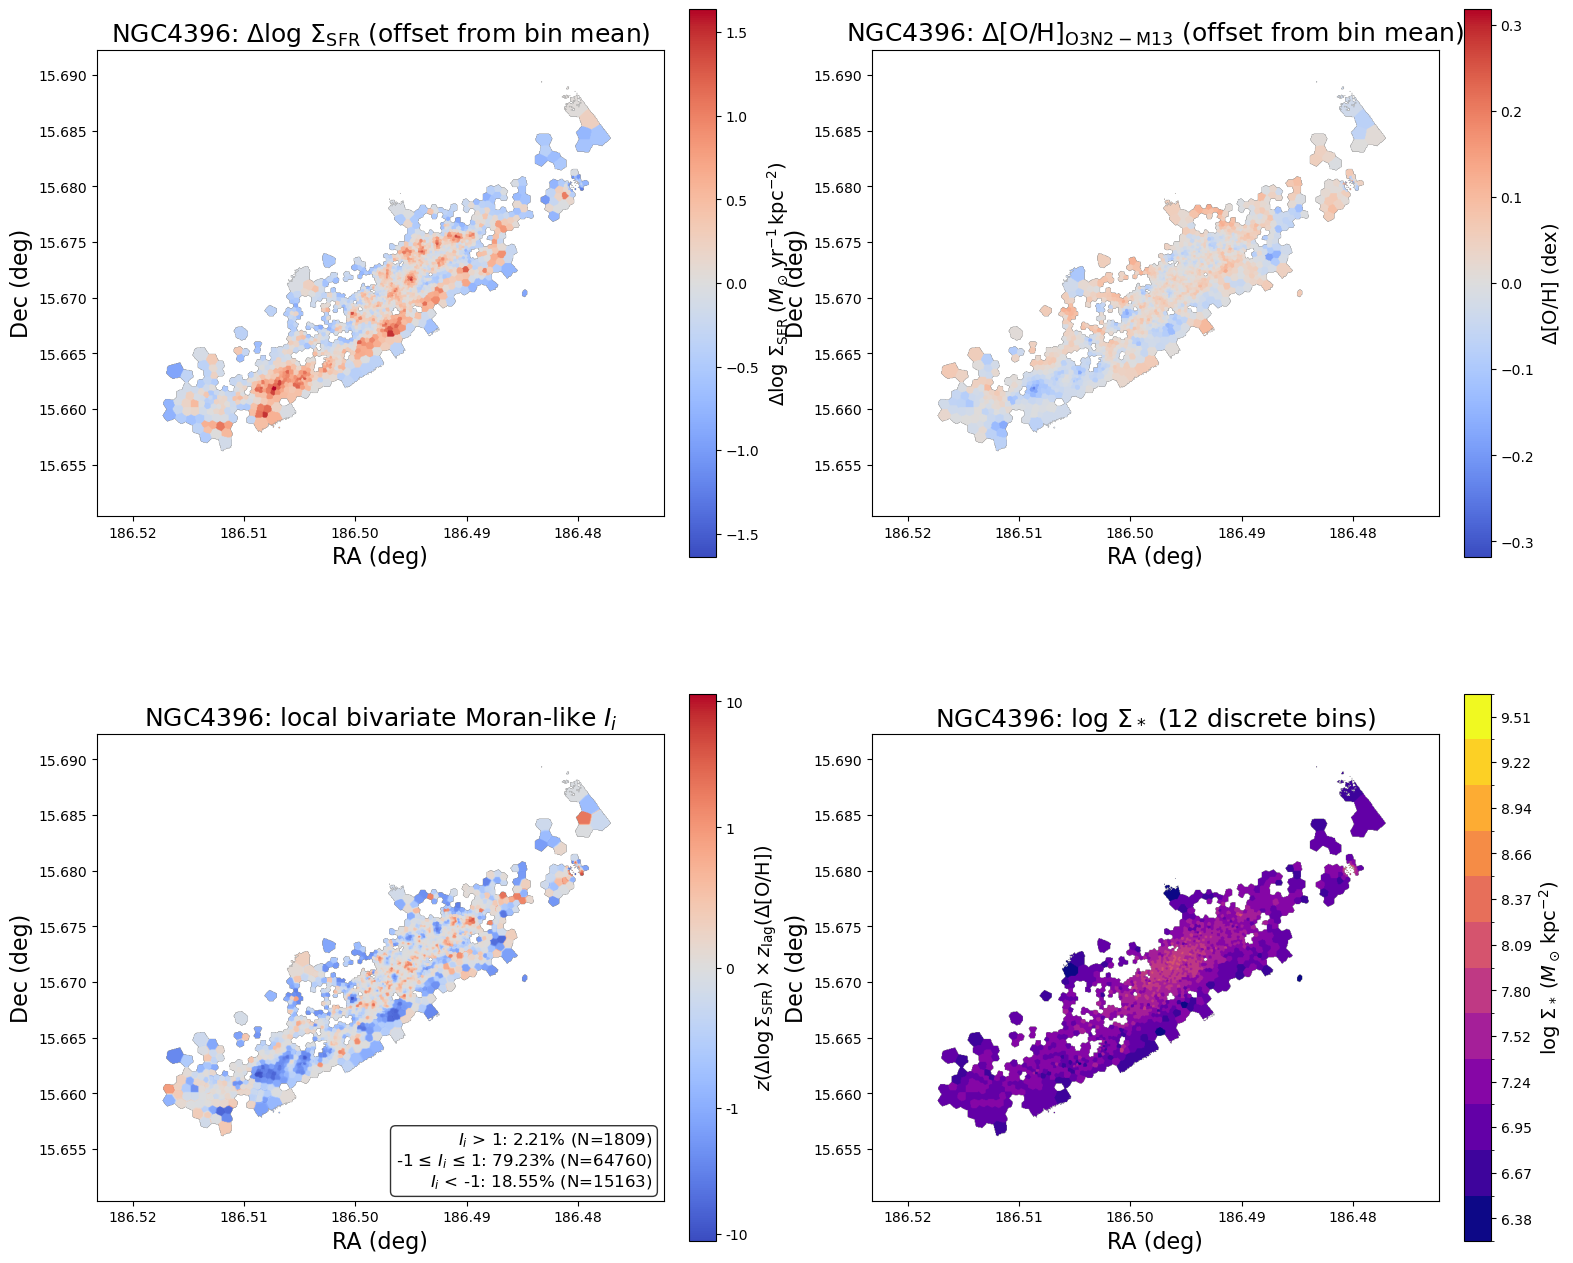


2x2 combined figure complete for NGC4396!
  Σ_SFR offset range: -1.638 to 1.638
  [O/H] offset range: -0.318 to 0.318
  Moran I_i range: -11.479 to 8.109
  Σ* bins: 12 bins from 6.241 to 9.651
  I_i > 1: 2.21% (N=1809)
  -1 ≤ I_i ≤ 1: 79.23% (N=64760)
  I_i < -1: 18.55% (N=15163)


In [7]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
        """
        Simple Moran-style local bivariate association between A and B.

        Parameters
        ----------
        A, B : 2D arrays
            Maps (e.g. sfr_offset, oh_offset).
        valid_mask : 2D bool
            True where both maps are valid.
        neighbourhood : {'queen', 'rook'}
            'queen' = 8-connected neighbours, 'rook' = 4-connected.

        Returns
        -------
        I_map : 2D array
            Local bivariate Moran-like statistic (sign & amplitude).
        quad_map : 2D int array
            Quadrant type:
            0 = invalid / no neighbours
            1 = high A, high lag(B)
            2 = low A,  high lag(B)
            3 = low A,  low lag(B)
            4 = high A, low lag(B)
        """
        ny, nx = A.shape
        I_map = np.full_like(A, np.nan, dtype=float)
        quad_map = np.zeros_like(A, dtype=int)

        # standardise A,B on valid pixels only
        Aval = A[valid_mask]
        Bval = B[valid_mask]
        Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
        Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

        if neighbourhood == 'queen':
            offsets = [(-1,-1), (-1,0), (-1,1),
                       ( 0,-1),          ( 0,1),
                       ( 1,-1), ( 1,0), ( 1,1)]
        elif neighbourhood == 'rook':
            offsets = [(-1,0), (0,-1), (0,1), (1,0)]
        else:
            raise ValueError("neighbourhood must be 'queen' or 'rook'")

        for i in range(ny):
            for j in range(nx):
                if not valid_mask[i, j]:
                    continue

                # collect neighbouring Bz values
                neigh_vals = []
                for dy, dx in offsets:
                    ii, jj = i + dy, j + dx
                    if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                        neigh_vals.append(Bz[ii, jj])

                if len(neigh_vals) == 0:
                    continue

                lag_B = np.mean(neigh_vals)   # spatial lag of B
                I_val = Az[i, j] * lag_B      # Moran-style product
                I_map[i, j] = I_val

                # quadrant classification (like LISA maps)
                if Az[i, j] >= 0 and lag_B >= 0:
                    quad_map[i, j] = 1  # high A – high B_neigh
                elif Az[i, j] < 0 and lag_B >= 0:
                    quad_map[i, j] = 2  # low A – high B_neigh
                elif Az[i, j] < 0 and lag_B < 0:
                    quad_map[i, j] = 3  # low A – low B_neigh
                else:
                    quad_map[i, j] = 4  # high A – low B_neigh

        return I_map, quad_map

    I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation using threshold parameter:
    #  - values between -threshold and +threshold are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=threshold, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Symmetric log-style ticks including ±threshold
    # Build positive log ticks
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    
    # Combine: negative log ticks + -threshold + 0 + threshold + positive log ticks
    # Remove threshold from pos_ticks if it's already a power of 10
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    
    ticks = neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered
    # Sort and remove duplicates
    ticks = sorted(set(ticks))
    
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])
    
    # Add legend for three classes based on threshold
    # Find best location by checking which corner has most NaN values
    ny, nx = I_map.shape
    corner_size = min(ny // 4, nx // 4)  # Check a quarter of the image size
    
    # Count NaN pixels in each corner
    corners = {
        'bottom_left': np.sum(np.isnan(I_map[:corner_size, :corner_size])),
        'bottom_right': np.sum(np.isnan(I_map[:corner_size, -corner_size:])),
        'top_left': np.sum(np.isnan(I_map[-corner_size:, :corner_size])),
        'top_right': np.sum(np.isnan(I_map[-corner_size:, -corner_size:]))
    }
    
    # Choose corner with most NaN values
    best_corner = max(corners, key=corners.get)
    
    # Set position and alignment based on best corner
    if best_corner == 'bottom_left':
        x_pos, y_pos = 0.02, 0.02
        va, ha = 'bottom', 'left'
    elif best_corner == 'bottom_right':
        x_pos, y_pos = 0.98, 0.02
        va, ha = 'bottom', 'right'
    elif best_corner == 'top_left':
        x_pos, y_pos = 0.02, 0.98
        va, ha = 'top', 'left'
    else:  # top_right
        x_pos, y_pos = 0.98, 0.98
        va, ha = 'top', 'right'
    
    legend_text = f'$I_i$ > {threshold}: {pct_high:.2f}% (N={n_high})\n-{threshold} ≤ $I_i$ ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})\n$I_i$ < -{threshold}: {pct_low:.2f}% (N={n_low})'
    ax3.text(x_pos, y_pos, legend_text, transform=ax3.transAxes, 
            fontsize=12, verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'{gal}_correlation_map_moran.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  I_i > {threshold}: {pct_high:.2f}% (N={n_high})")
    print(f"  -{threshold} ≤ I_i ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})")
    print(f"  I_i < -{threshold}: {pct_low:.2f}% (N={n_low})")


## 20251117 Verify the Offset maps

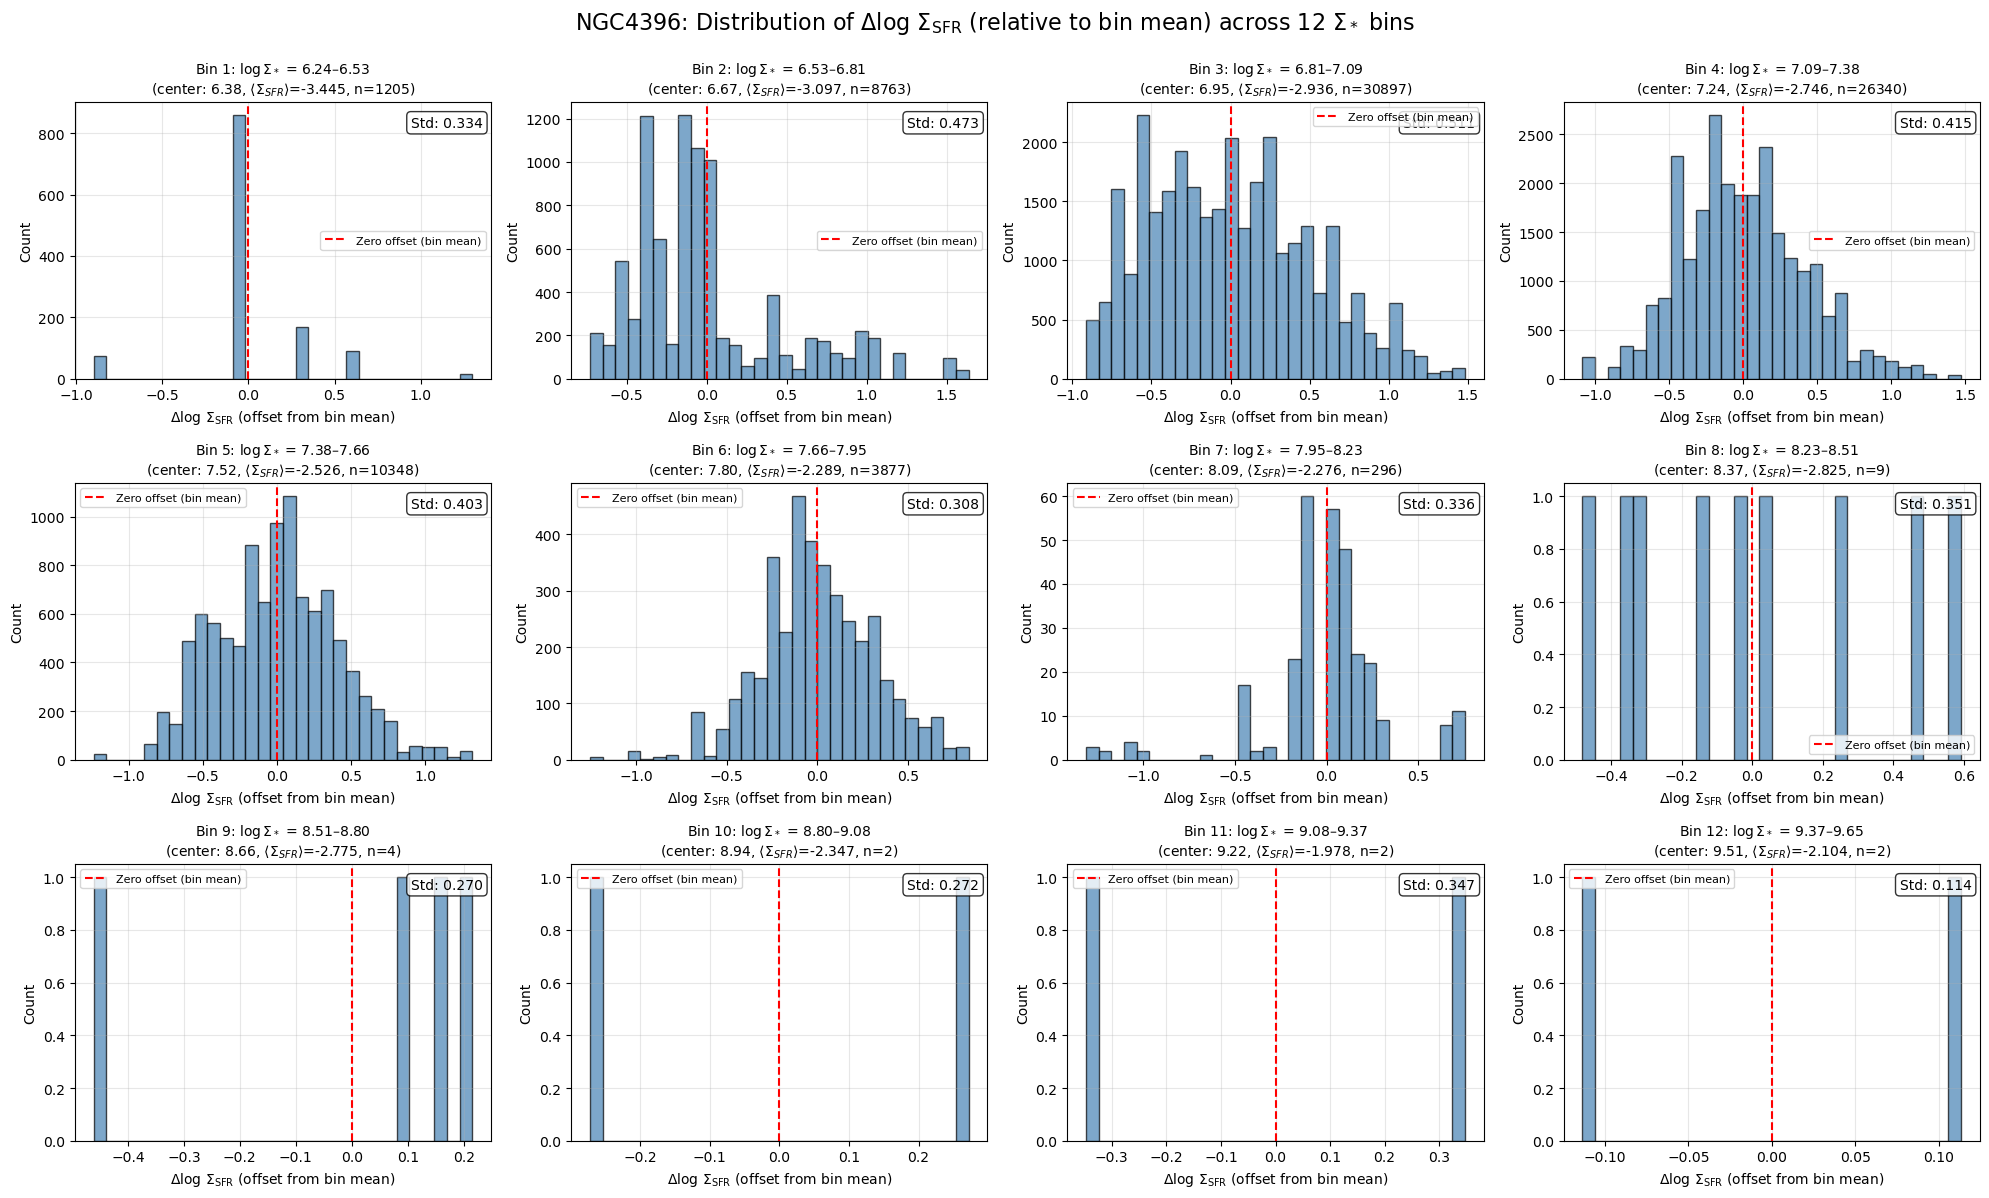


NGC4396: Σ_SFR offset statistics by Σ* bin (offset = Σ_SFR - mean(Σ_SFR in bin)):
Bin   Σ* range             n pixels   bin mean Σ_SFR       std offset     
-------------------------------------------------------------------------------------
1     6.24–6.53     1205       -3.445               0.334          
2     6.53–6.81     8763       -3.097               0.473          
3     6.81–7.09     30897      -2.936               0.511          
4     7.09–7.38     26340      -2.746               0.415          
5     7.38–7.66     10348      -2.526               0.403          
6     7.66–7.95     3877       -2.289               0.308          
7     7.95–8.23     296        -2.276               0.336          
8     8.23–8.51     9          -2.825               0.351          
9     8.51–8.80     4          -2.775               0.270          
10    8.80–9.08     2          -2.347               0.272          
11    9.08–9.37     2          -1.978               0.347          
12    9.

In [8]:
# ------------------------------------------------------------------
# Plot histogram of Σ_SFR offset for all 12 Σ* bins
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # ------------------------------------------------------------------
    # 3.  Create histogram for each bin (offset calculated per bin)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    axes = axes.flatten()
    
    for i in range(n_bins):
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Get Σ_SFR values in this bin
        sfr_bin = sigSFR[bin_mask]
        
        # Calculate offset WITHIN this bin (relative to bin mean)
        sfr_bin_mean = np.mean(sfr_bin)
        sfr_offset_bin = sfr_bin - sfr_bin_mean
        
        # Plot histogram
        axes[i].hist(sfr_offset_bin, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add vertical line at 0 (which is now the mean by definition)
        axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero offset (bin mean)')
        
        # Add statistics
        std_offset = np.std(sfr_offset_bin)
        axes[i].text(0.98, 0.95, f'Std: {std_offset:.3f}', transform=axes[i].transAxes,
                    fontsize=10, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Set title with bin range
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        axes[i].set_title(f'Bin {i+1}: $\\log\\Sigma_*$ = {sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}\n'
                         f'(center: {bin_center:.2f}, $\\langle\\Sigma_{{{{SFR}}}}\\rangle$={sfr_bin_mean:.3f}, n={np.sum(bin_mask)})', 
                         fontsize=10)
        axes[i].set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (offset from bin mean)', fontsize=10)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle(rf'{gal}: Distribution of $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (relative to bin mean) across 12 $\Sigma_*$ bins', 
                 fontsize=16, y=0.995)
    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_offset_histogram_by_SigmaM_bins.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'{gal}_SigmaSFR_offset_histogram_by_SigmaM_bins.pdf', bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n{gal}: Σ_SFR offset statistics by Σ* bin (offset = Σ_SFR - mean(Σ_SFR in bin)):")
    print(f"{'Bin':<5} {'Σ* range':<20} {'n pixels':<10} {'bin mean Σ_SFR':<20} {'std offset':<15}")
    print("-" * 85)
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        sfr_bin = sigSFR[bin_mask]
        sfr_bin_mean = np.mean(sfr_bin)
        sfr_offset_bin = sfr_bin - sfr_bin_mean
        std_offset = np.std(sfr_offset_bin)
        
        print(f"{i+1:<5} {sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}     "
              f"{np.sum(bin_mask):<10} {sfr_bin_mean:<20.3f} {std_offset:<15.3f}")


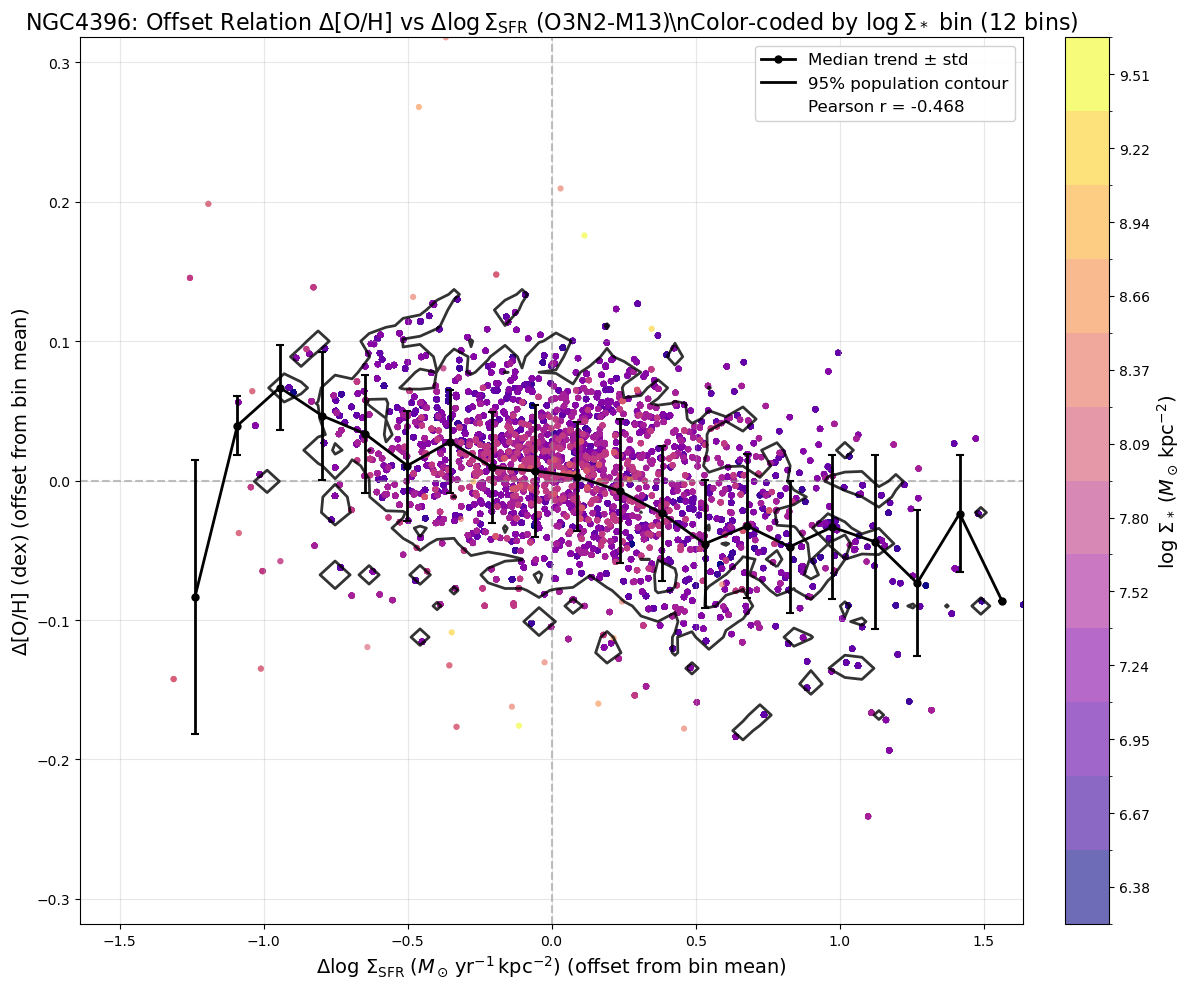


NGC4396: Offset relation plot complete!
  Total pixels plotted: 81,745
  Δlog(Σ_SFR) range: -1.313 to 1.638
  Δ[O/H] range: -0.241 to 0.318
  Number of Σ* bins: 12
  Σ* range: 6.241 to 9.651
  Pearson r = -0.468 (p = 0.000e+00)


In [9]:
# ------------------------------------------------------------------
# Plot offset relation: Δ[O/H] vs Δlog(Σ_SFR) for 12 Σ* bins
# Color-coded by Σ* bin (same as bottom-right panel of cell 8)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
from scipy.interpolate import interp1d

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # ------------------------------------------------------------------
    # 3.  Create scatter plot with color-coded Σ* bins
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # Collect all offset data for each bin
    all_delta_sfr = []
    all_delta_oh = []
    all_bin_colors = []
    
    for i in range(n_bins):
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Get values in this bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]
        
        # Calculate offsets WITHIN this bin (relative to bin mean)
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)
        
        sfr_offset_bin = sfr_bin - sfr_bin_mean
        oh_offset_bin = oh_bin - oh_bin_mean
        
        # Collect data
        all_delta_sfr.extend(sfr_offset_bin)
        all_delta_oh.extend(oh_offset_bin)
        all_bin_colors.extend([bin_centers[i]] * len(sfr_offset_bin))
    
    # Convert to arrays
    all_delta_sfr = np.array(all_delta_sfr)
    all_delta_oh = np.array(all_delta_oh)
    all_bin_colors = np.array(all_bin_colors)
    
    # Calculate Pearson correlation
    valid_corr = np.isfinite(all_delta_sfr) & np.isfinite(all_delta_oh)
    if np.sum(valid_corr) > 2:
        pearson_r, pearson_p = pearsonr(all_delta_sfr[valid_corr], all_delta_oh[valid_corr])
    else:
        pearson_r, pearson_p = np.nan, np.nan
    
    # Create scatter plot with color-coded points
    scatter = ax.scatter(all_delta_sfr, all_delta_oh, 
                        c=all_bin_colors, cmap=cmap_discrete, norm=norm_discrete,
                        s=20, alpha=0.6, edgecolors='none', rasterized=True)
    
    # ------------------------------------------------------------------
    # Calculate median trend with std error bars
    # ------------------------------------------------------------------
    # Create bins for x-axis (Δlog Σ_SFR)
    n_trend_bins = 20
    sfr_bins = np.linspace(np.nanmin(all_delta_sfr), np.nanmax(all_delta_sfr), n_trend_bins + 1)
    sfr_bin_centers = (sfr_bins[:-1] + sfr_bins[1:]) / 2
    
    medians = []
    stds = []
    
    for j in range(n_trend_bins):
        mask = (all_delta_sfr >= sfr_bins[j]) & (all_delta_sfr < sfr_bins[j+1])
        if np.sum(mask) > 0:
            medians.append(np.nanmedian(all_delta_oh[mask]))
            stds.append(np.nanstd(all_delta_oh[mask]))
        else:
            medians.append(np.nan)
            stds.append(np.nan)
    
    medians = np.array(medians)
    stds = np.array(stds)
    
    # Remove NaN values for plotting
    valid_trend = np.isfinite(medians) & np.isfinite(stds)
    if np.sum(valid_trend) > 0:
        ax.errorbar(sfr_bin_centers[valid_trend], medians[valid_trend], yerr=stds[valid_trend],
                   color='black', linewidth=2, marker='o', markersize=5, 
                   capsize=3, capthick=1.5, label='Median trend ± std', zorder=10)
    
    # ------------------------------------------------------------------
    # Add 95% population contour
    # ------------------------------------------------------------------
    from scipy.stats import gaussian_kde
    
    if np.sum(valid_corr) > 10:
        try:
            # Create a 2D histogram for contour
            H, xedges, yedges = np.histogram2d(all_delta_sfr[valid_corr], all_delta_oh[valid_corr], 
                                               bins=50, density=True)
            
            # Calculate cumulative distribution
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            
            # Find threshold for 95% of data
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
            
            # Create meshgrid for contour
            X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
            
            # Plot contour
            ax.contour(X, Y, H.T, levels=[threshold_95], colors='black', linewidths=2, 
                      linestyles='solid', alpha=0.8)
        except:
            pass  # Skip contour if it fails
    
    # Add zero reference lines
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=1)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, zorder=1)
    
    # Set symmetric axis limits
    max_abs_sfr = np.nanmax(np.abs(all_delta_sfr))
    max_abs_oh = np.nanmax(np.abs(all_delta_oh))
    ax.set_xlim(-max_abs_sfr, max_abs_sfr)
    ax.set_ylim(-max_abs_oh, max_abs_oh)
    
    # Labels and title
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$ (offset from bin mean)', 
                  fontsize=14)
    ax.set_ylabel(r'$\Delta$[O/H] (dex) (offset from bin mean)', fontsize=14)
    ax.set_title(rf'{gal}: Offset Relation Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ ({indicator_name})\n'
                 rf'Color-coded by $\log\Sigma_*$ bin ({n_bins} bins)', fontsize=16)
    
    # Add colorbar matching the binned Σ* map
    cbar = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])
    
    # Grid and legend
    ax.grid(True, alpha=0.3)
    
    # Create custom legend with Pearson r
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, marker='o', markersize=5, 
               label='Median trend ± std'),
        Line2D([0], [0], color='black', linewidth=2, linestyle='solid', 
               label='95% population contour'),
        Line2D([0], [0], color='none', label=f'Pearson r = {pearson_r:.3f}')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=12, framealpha=0.9)
    
    plt.tight_layout()
    # plt.savefig(f'{gal}_offset_relation_by_SigmaM_bins.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'{gal}_offset_relation_by_SigmaM_bins.pdf', bbox_inches='tight')
    plt.show()
    
    print(f"\n{gal}: Offset relation plot complete!")
    print(f"  Total pixels plotted: {len(all_delta_sfr):,}")
    print(f"  Δlog(Σ_SFR) range: {np.nanmin(all_delta_sfr):.3f} to {np.nanmax(all_delta_sfr):.3f}")
    print(f"  Δ[O/H] range: {np.nanmin(all_delta_oh):.3f} to {np.nanmax(all_delta_oh):.3f}")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Pearson r = {pearson_r:.3f} (p = {pearson_p:.3e})")


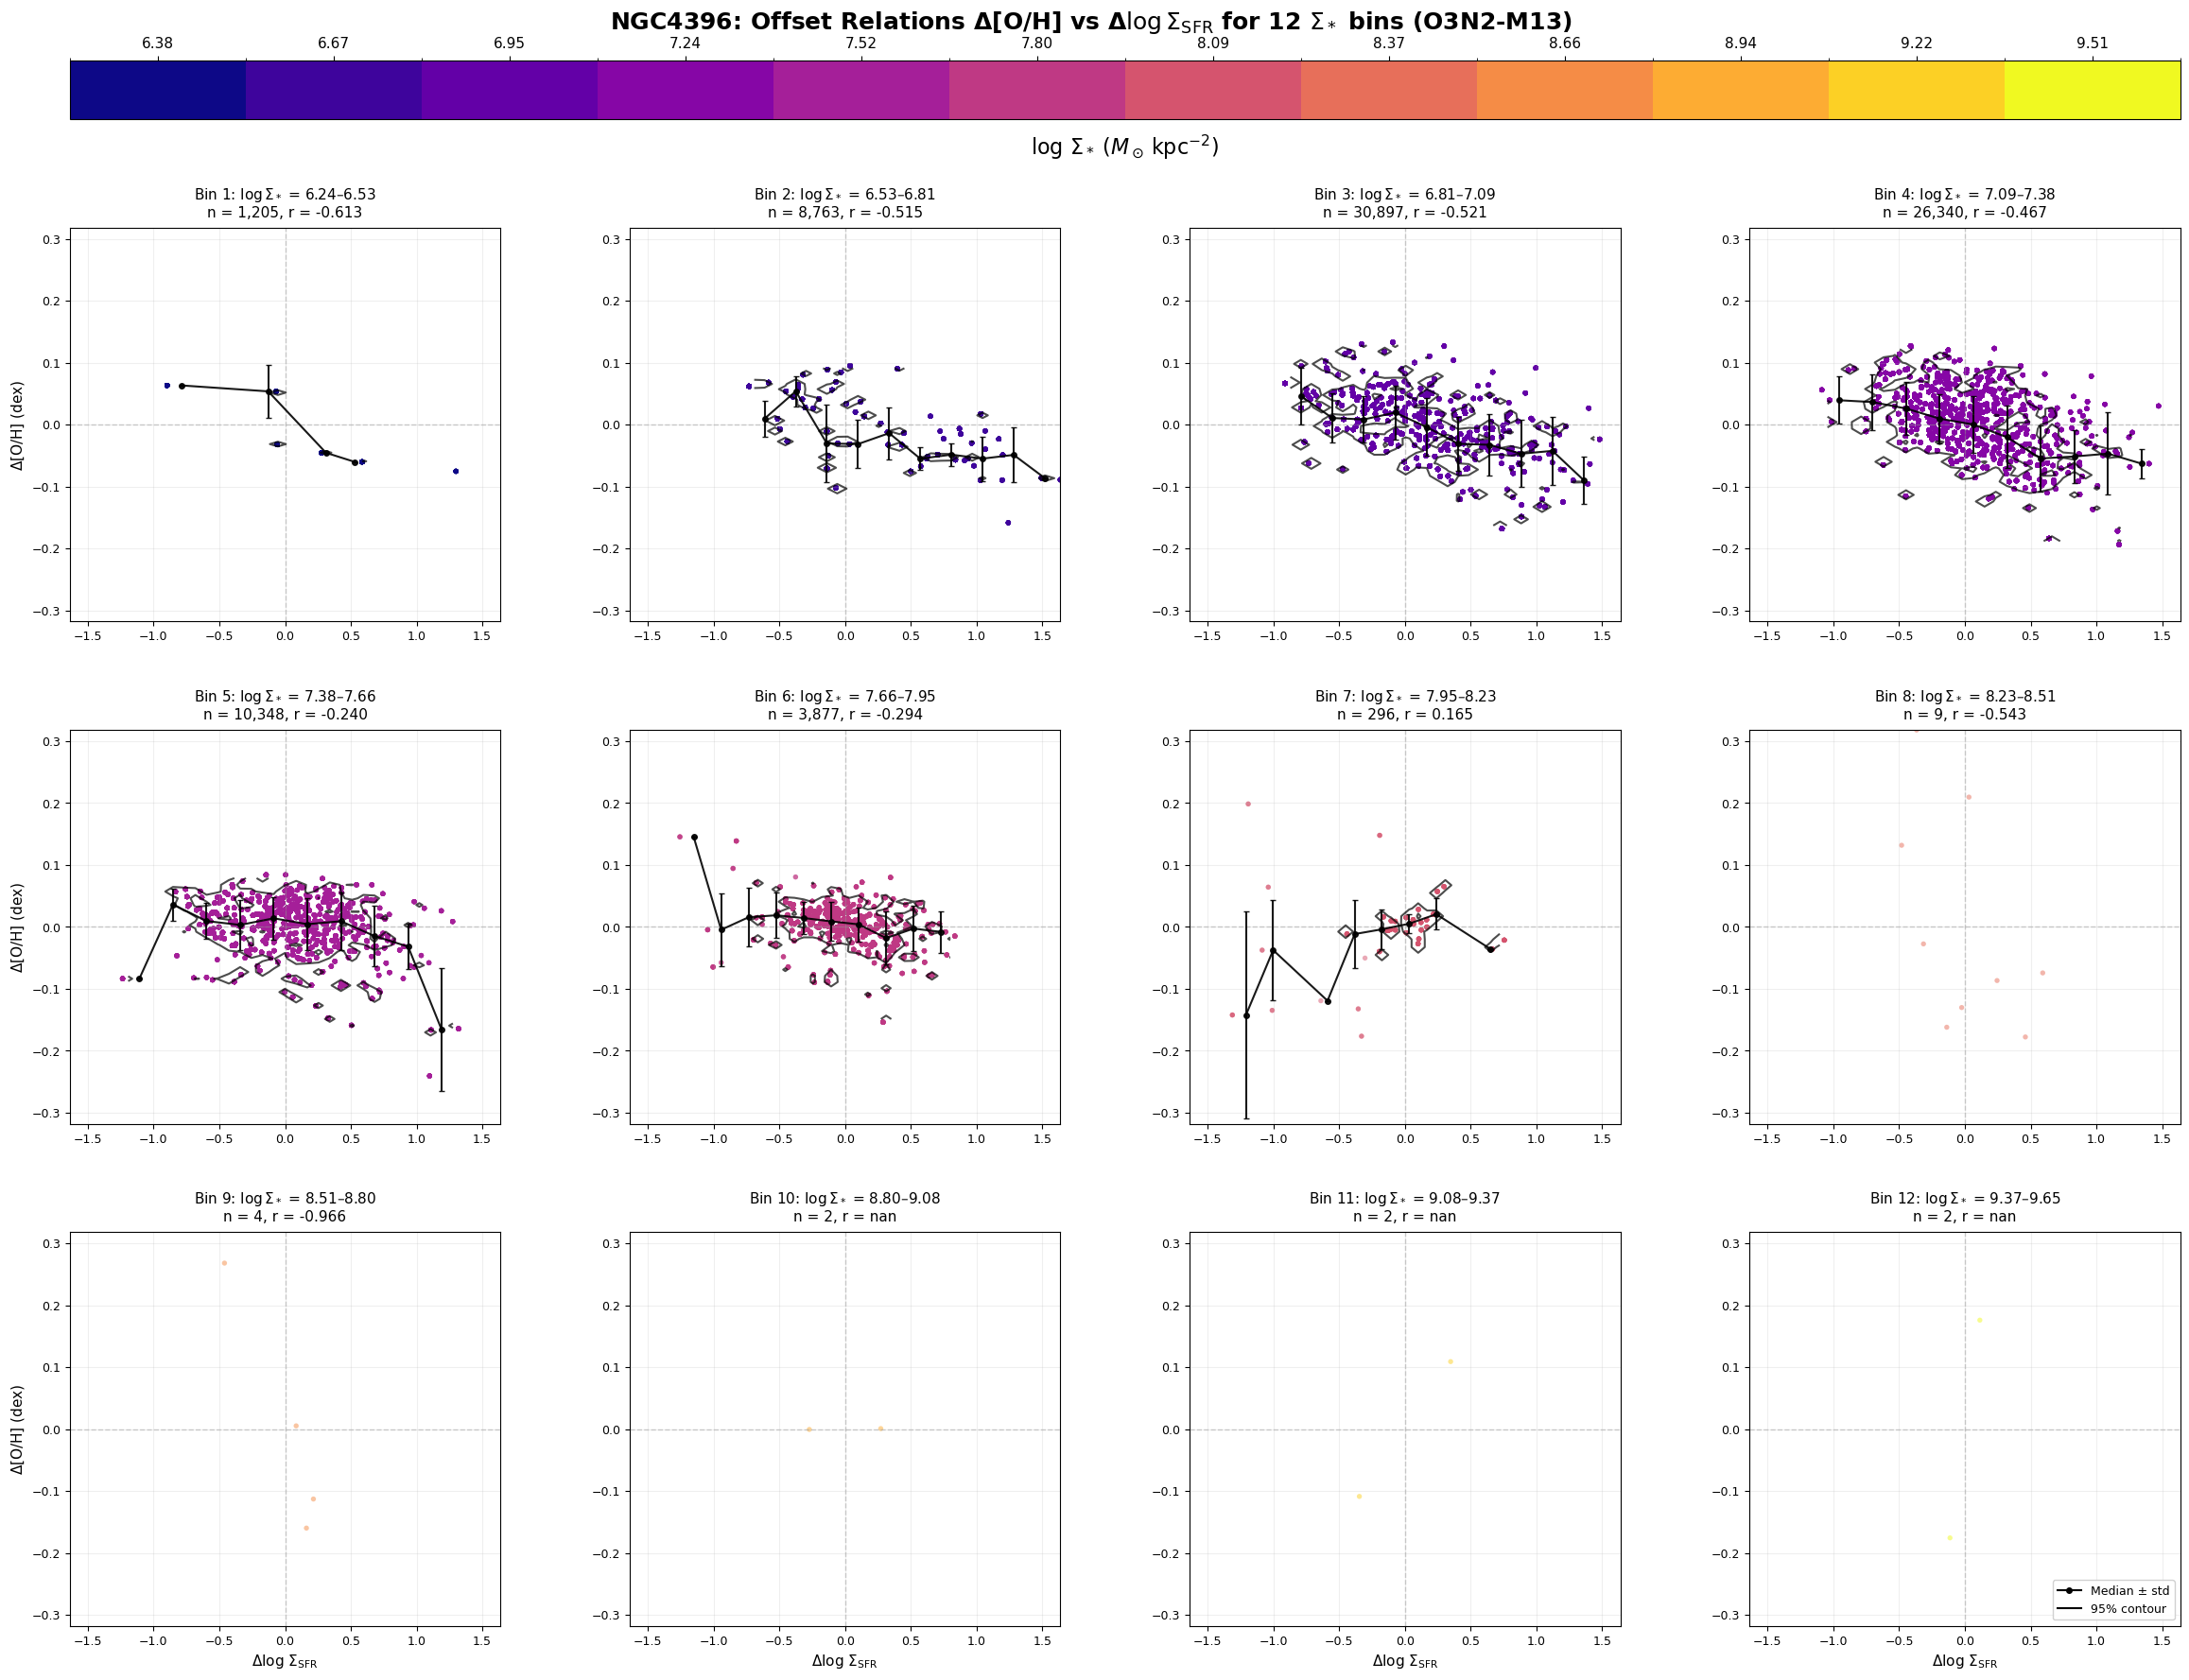


NGC4396: 12-panel offset relation grid complete!
  Number of Σ* bins: 12
  Σ* range: 6.241 to 9.651
  Global Δlog(Σ_SFR) axis limits: ±1.638
  Global Δ[O/H] axis limits: ±0.318


In [10]:
# ------------------------------------------------------------------
# Plot 12 separate offset relations (one per Σ* bin) in 3x4 grid
# With shared colorbar at the top
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 3.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 4.  Create 3x4 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid: 1 row for colorbar, 3 rows for subplots
    gs = gridspec.GridSpec(4, 4, figure=fig, 
                          height_ratios=[0.15, 1, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.96, bottom=0.04, left=0.05, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 12 subplots in 3x4 grid
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 5.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Calculate Pearson correlation for this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            if np.sum(valid_corr) > 2:
                pearson_r, pearson_p = pearsonr(sfr_offset[valid_corr], oh_offset[valid_corr])
            else:
                pearson_r, pearson_p = np.nan, np.nan
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot
            ax.scatter(sfr_offset, oh_offset, 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate median trend with std error bars
            # ------------------------------------------------------------------
            n_trend_bins = 10
            if np.sum(valid_corr) > n_trend_bins:
                sfr_bins = np.linspace(np.nanmin(sfr_offset[valid_corr]), 
                                      np.nanmax(sfr_offset[valid_corr]), n_trend_bins + 1)
                sfr_bin_centers = (sfr_bins[:-1] + sfr_bins[1:]) / 2
                
                medians = []
                stds = []
                
                for j in range(n_trend_bins):
                    mask = (sfr_offset >= sfr_bins[j]) & (sfr_offset < sfr_bins[j+1]) & valid_corr
                    if np.sum(mask) > 0:
                        medians.append(np.nanmedian(oh_offset[mask]))
                        stds.append(np.nanstd(oh_offset[mask]))
                    else:
                        medians.append(np.nan)
                        stds.append(np.nan)
                
                medians = np.array(medians)
                stds = np.array(stds)
                
                # Remove NaN values for plotting
                valid_trend = np.isfinite(medians) & np.isfinite(stds)
                if np.sum(valid_trend) > 0:
                    ax.errorbar(sfr_bin_centers[valid_trend], medians[valid_trend], 
                               yerr=stds[valid_trend],
                               color='black', linewidth=1.5, marker='o', markersize=4, 
                               capsize=2, capthick=1, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Add 95% population contour
            # ------------------------------------------------------------------
            if np.sum(valid_corr) > 20:
                try:
                    # Create a 2D histogram for contour
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr], 
                                                       bins=30, density=True)
                    
                    # Calculate cumulative distribution
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    
                    # Find threshold for 95% of data
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create meshgrid for contour
                    X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
                    
                    # Plot contour
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black', 
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except:
                    pass  # Skip contour if it fails
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Title with bin info and Pearson r
            ax.set_title(f'Bin {i+1}: $\\log\\Sigma_*$ = {sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}\n'
                        f'n = {n_pixels:,}, r = {pearson_r:.3f}',
                        fontsize=11, pad=8)
            
            # Labels (only on left and bottom edges)
            if i % 4 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 8:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 6.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    # Create a dummy mappable for the colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    # Add colorbar to the top axis
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    # Overall title
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for 12 $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    # Add legend to bottom-right subplot explaining the black features
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=1.5, marker='o', markersize=4,
               label='Median ± std'),
        Line2D([0], [0], color='black', linewidth=1.5, linestyle='solid',
               label='95% contour')
    ]
    axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
    
    # plt.savefig(f'{gal}_offset_relations_12bins_grid.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'{gal}_offset_relations_12bins_grid.pdf', bbox_inches='tight')
    plt.show()
    
    print(f"\n{gal}: 12-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")
